# Comparaison Baseline vs Finetune — Prompt Clinical Matching

Compare les scores (accuracy) et les erreurs entre le modèle baseline et le modèle finetuné, **globalement** et par type d'énoncé (**POL** vs **MEDICAL**).

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Dossier de sortie des graphiques (même convention que les autres notebooks du dossier)
GRAPHS_DIR = "graphes"
os.makedirs(GRAPHS_DIR, exist_ok=True)

# Chargement des CSV combined (baseline et finetune)
df_base = pd.read_csv("eval_clinical_matching_combined_baseline.csv")
df_fine = pd.read_csv("eval_clinical_matching_combined_finetune.csv")

# Fusion sur index pour comparer exemple par exemple
df = df_base[["index", "statement_type", "gold"]].copy()
df["pred_baseline"] = df_base["prediction"]
df["pred_finetune"] = df_fine["prediction"]
df["correct_baseline"] = df_base["is_correct"]
df["correct_finetune"] = df_fine["is_correct"]

print("Lignes chargées:", len(df))
df.head()

Lignes chargées: 3156


,index,statement_type,gold,pred_baseline,pred_finetune,correct_baseline,correct_finetune
0,0,pol,Entailment,Contradiction,Contradiction,False,False
1,1,pol,Contradiction,Entailment,Entailment,False,False
2,2,pol,Entailment,Entailment,Entailment,True,True
3,3,pol,Contradiction,Contradiction,Contradiction,True,True
4,4,pol,Contradiction,Contradiction,Entailment,True,False


Accuracy (0–1) :


,Baseline,Finetune,Δ
statement_type,,,
medical,0.673638,0.723701,0.0501
pol,0.649556,0.732573,0.0830
Global,0.661597,0.728137,0.0665


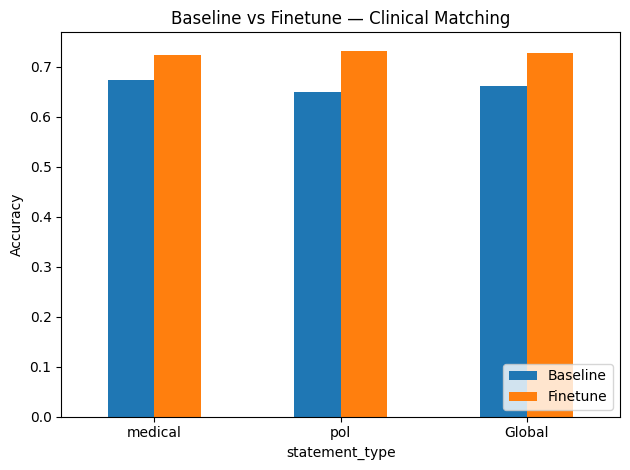

In [6]:
# Scores : accuracy globale et par statement_type
scores = pd.DataFrame({
    "Baseline": df.groupby("statement_type")["correct_baseline"].mean(),
    "Finetune":  df.groupby("statement_type")["correct_finetune"].mean(),
})
scores.loc["Global"] = [df["correct_baseline"].mean(), df["correct_finetune"].mean()]
scores["Δ"] = (scores["Finetune"] - scores["Baseline"]).round(4)
print("Accuracy (0–1) :")
display(scores)
scores[["Baseline", "Finetune"]].plot(kind="bar", ylabel="Accuracy", title="Baseline vs Finetune — Clinical Matching", rot=0);
plt.legend(loc="lower right");
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "clinical_matching_compare_baseline_finetune_accuracy.png"), dpi=150, bbox_inches="tight");
plt.show();

Répartition des accords / désaccords :


,Les deux corrects,"Baseline faux, Finetune OK","Baseline OK, Finetune faux",Les deux faux
Global,1656,642,432,426
POL,813,343,212,210
MEDICAL,843,299,220,216


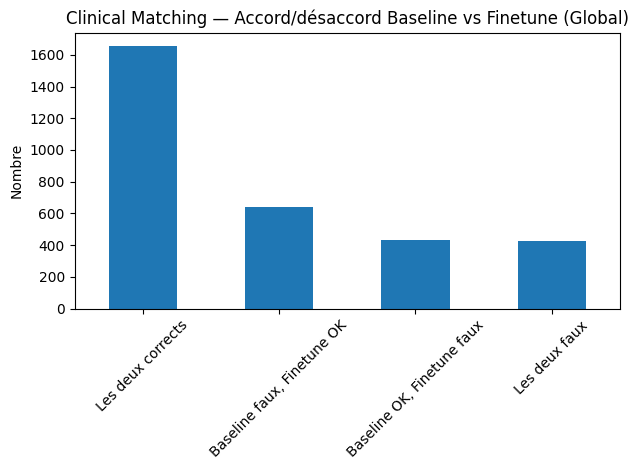

In [7]:
# Où se trompent-ils ? (mêmes endroits)
df["both_ok"]    = df["correct_baseline"] & df["correct_finetune"]
df["base_wrong"] = ~df["correct_baseline"] & df["correct_finetune"]   # finetune répare
df["fine_wrong"] = df["correct_baseline"] & ~df["correct_finetune"]   # régression
df["both_wrong"] = ~df["correct_baseline"] & ~df["correct_finetune"]  # même erreur

counts = pd.DataFrame({
    "Les deux corrects": [df["both_ok"].sum(), df[df["statement_type"]=="pol"]["both_ok"].sum(), df[df["statement_type"]=="medical"]["both_ok"].sum()],
    "Baseline faux, Finetune OK": [df["base_wrong"].sum(), df[df["statement_type"]=="pol"]["base_wrong"].sum(), df[df["statement_type"]=="medical"]["base_wrong"].sum()],
    "Baseline OK, Finetune faux": [df["fine_wrong"].sum(), df[df["statement_type"]=="pol"]["fine_wrong"].sum(), df[df["statement_type"]=="medical"]["fine_wrong"].sum()],
    "Les deux faux": [df["both_wrong"].sum(), df[df["statement_type"]=="pol"]["both_wrong"].sum(), df[df["statement_type"]=="medical"]["both_wrong"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Répartition des accords / désaccords :")
display(counts)
# Graphique : répartition des 4 cas (global)
counts_global = counts.loc["Global"]
counts_global.plot(kind="bar", ylabel="Nombre", title="Clinical Matching — Accord/désaccord Baseline vs Finetune (Global)", rot=45);
plt.tight_layout();
plt.savefig(os.path.join(GRAPHS_DIR, "clinical_matching_compare_baseline_finetune_accord_desaccord.png"), dpi=150, bbox_inches="tight");
plt.show();

In [8]:
# Chevauchement des erreurs : % erreurs baseline corrigées, % régressions finetune
err_base = ~df["correct_baseline"]
err_fine = ~df["correct_finetune"]
fixed = err_base & df["correct_finetune"]
new_err = df["correct_baseline"] & err_fine

overlap = pd.DataFrame({
    "Erreurs baseline": [err_base.sum(), err_base[df["statement_type"]=="pol"].sum(), err_base[df["statement_type"]=="medical"].sum()],
    "% corrigées par finetune": [
        (fixed.sum() / err_base.sum() * 100) if err_base.sum() else 0,
        (fixed[df["statement_type"]=="pol"].sum() / err_base[df["statement_type"]=="pol"].sum() * 100) if err_base[df["statement_type"]=="pol"].sum() else 0,
        (fixed[df["statement_type"]=="medical"].sum() / err_base[df["statement_type"]=="medical"].sum() * 100) if err_base[df["statement_type"]=="medical"].sum() else 0,
    ],
    "Nouvelles erreurs finetune": [new_err.sum(), new_err[df["statement_type"]=="pol"].sum(), new_err[df["statement_type"]=="medical"].sum()],
}, index=["Global", "POL", "MEDICAL"])
print("Synthèse erreurs :")
display(overlap.round(2))

Synthèse erreurs :


,Erreurs baseline,% corrigées par finetune,Nouvelles erreurs finetune
Global,1068,60.11,432
POL,553,62.03,212
MEDICAL,515,58.06,220
